In [18]:
import random
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
def theoretical_metrics(lambda1, lambda2, mu):
    rho1 = lambda1 / mu
    rho2 = lambda2 / mu
    rho = rho1 + rho2
    if rho >= 1:
        raise ValueError('Система неустойчива')
    ws1 = 1 / (mu - lambda1)
    wq1 = ws1 - 1 / mu
    ws2 = 1 / (mu * (1 - rho1) * (1 - rho))
    wq2 = ws2 - 1 / mu
    return {
        'Wq1': wq1,
        'Ws1': ws1,
        'Pwait1': rho1,
        'Wq2': wq2,
        'Ws2': ws2,
        'Pwait2': rho,
        'Load': rho,
        'L': lambda1 * ws1 + lambda2 * ws2
    }

In [20]:
def simulate_priority_parking(lambda1, lambda2, mu, t_max=1000, seed=42):
    rng = random.Random(seed)
    t = 0.0
    next_high = rng.expovariate(lambda1) if lambda1 > 0 else float('inf')
    next_low = rng.expovariate(lambda2) if lambda2 > 0 else float('inf')
    next_departure = float('inf')
    current = None
    high_queue = deque()
    low_queue = deque()
    arrivals_1 = 0
    arrivals_2 = 0
    waits_1 = []
    waits_2 = []
    system_1 = []
    system_2 = []
    pwait_count_1 = 0
    pwait_count_2 = 0
    busy_time = 0.0
    area_n = 0.0

    def total_in_system():
        return len(high_queue) + len(low_queue) + (1 if current is not None else 0)

    def start_service(job, now):
        nonlocal current, next_departure
        job['wait'] += now - job['queue_enter']
        current = job
        next_departure = now + rng.expovariate(mu)

    while True:
        t_next = min(next_high, next_low, next_departure)

        if t < t_max < t_next:
            dt = t_max - t
            if current is not None:
                busy_time += dt
            area_n += total_in_system() * dt
            t = t_max
            next_high = float('inf')
            next_low = float('inf')
            continue

        if t < t_max:
            observed_dt = min(t_next, t_max) - t
            if observed_dt > 0:
                if current is not None:
                    busy_time += observed_dt
                area_n += total_in_system() * observed_dt
        t = t_next

        if t == float('inf'):
            break

        if next_high <= next_low and next_high <= next_departure:
            arrivals_1 += 1
            job = {'class': 1, 'arrival': t, 'queue_enter': t, 'wait': 0.0}
            if current is None:
                start_service(job, t)
            elif current['class'] == 2:
                current['queue_enter'] = t
                low_queue.appendleft(current)
                start_service(job, t)
            else:
                pwait_count_1 += 1
                high_queue.append(job)
            next_high = t + rng.expovariate(lambda1) if t < t_max else float('inf')
        elif next_low <= next_high and next_low <= next_departure:
            arrivals_2 += 1
            job = {'class': 2, 'arrival': t, 'queue_enter': t, 'wait': 0.0}
            if current is None:
                start_service(job, t)
            else:
                pwait_count_2 += 1
                low_queue.append(job)
            next_low = t + rng.expovariate(lambda2) if t < t_max else float('inf')
        else:
            finished = current
            if finished['class'] == 1:
                waits_1.append(finished['wait'])
                system_1.append(t - finished['arrival'])
            else:
                waits_2.append(finished['wait'])
                system_2.append(t - finished['arrival'])

            if high_queue:
                start_service(high_queue.popleft(), t)
            elif low_queue:
                start_service(low_queue.popleft(), t)
            else:
                current = None
                next_departure = float('inf')

        if next_high == next_low == next_departure == float('inf') and current is None and not high_queue and not low_queue:
            break

    return {
        'arrivals_1': arrivals_1,
        'arrivals_2': arrivals_2,
        'served_1': len(system_1),
        'served_2': len(system_2),
        'Wq1': sum(waits_1) / len(waits_1) if waits_1 else 0.0,
        'Ws1': sum(system_1) / len(system_1) if system_1 else 0.0,
        'Pwait1': pwait_count_1 / arrivals_1 if arrivals_1 else 0.0,
        'Wq2': sum(waits_2) / len(waits_2) if waits_2 else 0.0,
        'Ws2': sum(system_2) / len(system_2) if system_2 else 0.0,
        'Pwait2': pwait_count_2 / arrivals_2 if arrivals_2 else 0.0,
        'Load': busy_time / t_max,
        'L': area_n / t_max
    }

In [21]:
lambda1 = 0.3
lambda2 = 0.55
mu = 1.0
t_max = 1000

simulation = simulate_priority_parking(lambda1, lambda2, mu, t_max=t_max, seed=42)
theory = theoretical_metrics(lambda1, lambda2, mu)

base_result = pd.DataFrame({
    'Показатель': [
        'Высокоприоритетных прибыло',
        'Низкоприоритетных прибыло',
        'Wq1',
        'Ws1',
        'P ожидания 1',
        'Wq2',
        'Ws2',
        'P ожидания 2',
        'Загрузка',
        'L'
    ],
    'Эксперимент': [
        simulation['arrivals_1'],
        simulation['arrivals_2'],
        simulation['Wq1'],
        simulation['Ws1'],
        simulation['Pwait1'],
        simulation['Wq2'],
        simulation['Ws2'],
        simulation['Pwait2'],
        simulation['Load'],
        simulation['L']
    ],
    'Теория': [
        lambda1 * t_max,
        lambda2 * t_max,
        theory['Wq1'],
        theory['Ws1'],
        theory['Pwait1'],
        theory['Wq2'],
        theory['Ws2'],
        theory['Pwait2'],
        theory['Load'],
        theory['L']
    ]
})
base_result

,Показатель,Эксперимент,Теория
0,Высокоприоритетных прибыло,295.000000,300.000000
1,Низкоприоритетных прибыло,559.000000,550.000000
2,Wq1,0.467494,0.428571
3,Ws1,1.555837,1.428571
4,P ожидания 1,0.338983,0.300000
5,Wq2,8.666169,8.523810
6,Ws2,9.665977,9.523810
7,P ожидания 2,0.876565,0.850000
8,Загрузка,0.879900,0.850000
9,L,5.862199,5.666667


In [22]:
lambda2_values = [0.10, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
rows = []

for current_lambda2 in lambda2_values:
    sim = simulate_priority_parking(0.3, current_lambda2, 1.0, t_max=t_max, seed=100 + int(current_lambda2 * 100))
    th = theoretical_metrics(0.3, current_lambda2, 1.0)
    rows.append([
        current_lambda2,
        sim['Wq1'], th['Wq1'],
        sim['Wq2'], th['Wq2'],
        sim['Ws1'], th['Ws1'],
        sim['Ws2'], th['Ws2'],
        sim['Pwait1'], th['Pwait1'],
        sim['Pwait2'], th['Pwait2'],
        sim['Load'], th['Load'],
        sim['L'], th['L']
    ])

table_lambda2 = pd.DataFrame(rows, columns=[
    'λ2',
    'Wq1 эксп', 'Wq1 теор',
    'Wq2 эксп', 'Wq2 теор',
    'Ws1 эксп', 'Ws1 теор',
    'Ws2 эксп', 'Ws2 теор',
    'Pож1 эксп', 'Pож1 теор',
    'Pож2 эксп', 'Pож2 теор',
    'Загр эксп', 'Загр теор',
    'L эксп', 'L теор'
]).round(6)
table_lambda2

,λ2,Wq1 эксп,Wq1 теор,Wq2 эксп,Wq2 теор,Ws1 эксп,Ws1 теор,Ws2 эксп,Ws2 теор,Pож1 эксп,Pож1 теор,Pож2 эксп,Pож2 теор,Загр эксп,Загр теор,L эксп,L теор
0,0.10,0.413718,0.428571,1.476092,1.380952,1.512110,1.428571,2.505071,2.380952,0.300676,0.3,0.455357,0.40,0.435123,0.40,0.717869,0.666667
1,0.20,0.261340,0.428571,1.707895,1.857143,1.192946,1.428571,2.778671,2.857143,0.272085,0.3,0.542222,0.50,0.504569,0.50,0.962805,1.000000
2,0.30,0.705194,0.428571,3.496163,2.571429,1.749867,1.428571,4.408281,3.571429,0.309904,0.3,0.610932,0.60,0.609441,0.60,1.917473,1.500000
3,0.35,0.429134,0.428571,3.493304,3.081633,1.384090,1.428571,4.493498,4.081633,0.311526,0.3,0.625000,0.65,0.670768,0.65,2.081493,1.857143
4,0.40,0.465148,0.428571,3.861169,3.761905,1.521458,1.428571,4.891767,4.761905,0.306050,0.3,0.743056,0.70,0.742041,0.70,2.540773,2.333333
5,0.45,0.589636,0.428571,5.517860,4.714286,1.536163,1.428571,6.557251,5.714286,0.305732,0.3,0.726862,0.75,0.747160,0.75,3.307733,3.000000
6,0.50,0.346188,0.428571,4.402937,6.142857,1.354284,1.428571,5.377742,7.142857,0.292254,0.3,0.744681,0.80,0.744458,0.80,2.912156,4.000000
7,0.55,0.483372,0.428571,6.228947,8.523810,1.488142,1.428571,7.271499,9.523810,0.324415,0.3,0.849130,0.85,0.839426,0.85,4.204319,5.666667
8,0.60,0.470936,0.428571,12.642184,13.285714,1.512094,1.428571,13.660310,14.285714,0.325342,0.3,0.893964,0.90,0.919850,0.90,8.772321,9.000000


In [23]:
mu_values = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8]
rows = []

for current_mu in mu_values:
    sim = simulate_priority_parking(0.3, 0.55, current_mu, t_max=t_max, seed=200 + int(current_mu * 100))
    th = theoretical_metrics(0.3, 0.55, current_mu)
    rows.append([
        current_mu,
        sim['Wq1'], th['Wq1'],
        sim['Wq2'], th['Wq2'],
        sim['Ws1'], th['Ws1'],
        sim['Ws2'], th['Ws2'],
        sim['Pwait1'], th['Pwait1'],
        sim['Pwait2'], th['Pwait2'],
        sim['Load'], th['Load'],
        sim['L'], th['L']
    ])

table_mu = pd.DataFrame(rows, columns=[
    'μ',
    'Wq1 эксп', 'Wq1 теор',
    'Wq2 эксп', 'Wq2 теор',
    'Ws1 эксп', 'Ws1 теор',
    'Ws2 эксп', 'Ws2 теор',
    'Pож1 эксп', 'Pож1 теор',
    'Pож2 эксп', 'Pож2 теор',
    'Загр эксп', 'Загр теор',
    'L эксп', 'L теор'
]).round(6)
table_mu

,μ,Wq1 эксп,Wq1 теор,Wq2 эксп,Wq2 теор,Ws1 эксп,Ws1 теор,Ws2 эксп,Ws2 теор,Pож1 эксп,Pож1 теор,Pож2 эксп,Pож2 теор,Загр эксп,Загр теор,L эксп,L теор
0,1.0,0.327960,0.428571,6.240493,8.523810,1.299937,1.428571,7.257743,9.523810,0.265781,0.300000,0.807050,0.850000,0.836025,0.850000,4.283457,5.666667
1,1.1,0.364085,0.340909,3.196066,4.590909,1.164464,1.250000,4.071449,5.500000,0.268707,0.272727,0.701689,0.772727,0.701890,0.772727,2.512435,3.400000
2,1.2,0.202002,0.277778,2.845224,2.976190,0.956572,1.111111,3.749776,3.809524,0.234899,0.250000,0.720293,0.708333,0.719237,0.708333,2.335771,2.428571
3,1.3,0.267577,0.230769,2.838384,2.119658,1.100112,1.000000,3.639485,2.888889,0.267742,0.230769,0.707231,0.653846,0.712310,0.653846,2.404623,1.888889
4,1.4,0.171745,0.194805,1.189502,1.599764,0.863506,0.909091,1.909991,2.314050,0.175258,0.214286,0.598616,0.607143,0.614452,0.607143,1.350063,1.545455
5,1.5,0.134774,0.166667,1.244879,1.256410,0.759203,0.833333,1.968811,1.923077,0.224832,0.200000,0.570342,0.566667,0.566869,0.566667,1.261837,1.307692
6,1.6,0.103211,0.144231,1.013267,1.016026,0.742414,0.769231,1.629861,1.641026,0.177474,0.187500,0.525217,0.531250,0.541828,0.531250,1.154697,1.133333
7,1.7,0.103165,0.126050,0.871393,0.840336,0.700580,0.714286,1.506702,1.428571,0.157191,0.176471,0.541133,0.500000,0.526141,0.500000,1.033639,1.000000
8,1.8,0.076139,0.111111,0.634891,0.707602,0.568784,0.666667,1.184741,1.263158,0.163823,0.166667,0.414538,0.472222,0.424218,0.472222,0.769687,0.894737


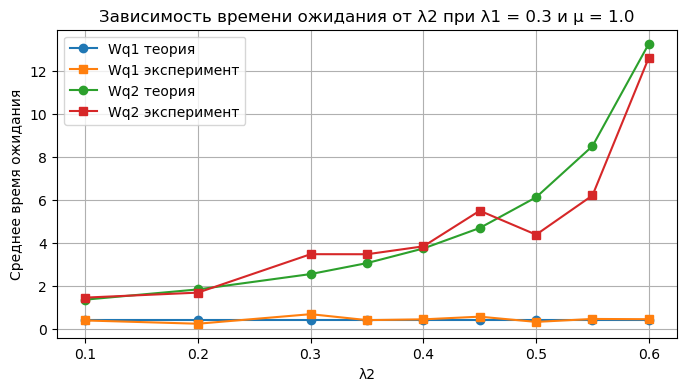

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(table_lambda2['λ2'], table_lambda2['Wq1 теор'], marker='o', label='Wq1 теория')
plt.plot(table_lambda2['λ2'], table_lambda2['Wq1 эксп'], marker='s', label='Wq1 эксперимент')
plt.plot(table_lambda2['λ2'], table_lambda2['Wq2 теор'], marker='o', label='Wq2 теория')
plt.plot(table_lambda2['λ2'], table_lambda2['Wq2 эксп'], marker='s', label='Wq2 эксперимент')
plt.xlabel('λ2')
plt.ylabel('Среднее время ожидания')
plt.title('Зависимость времени ожидания от λ2 при λ1 = 0.3 и μ = 1.0')
plt.grid(True)
plt.legend()
plt.show()

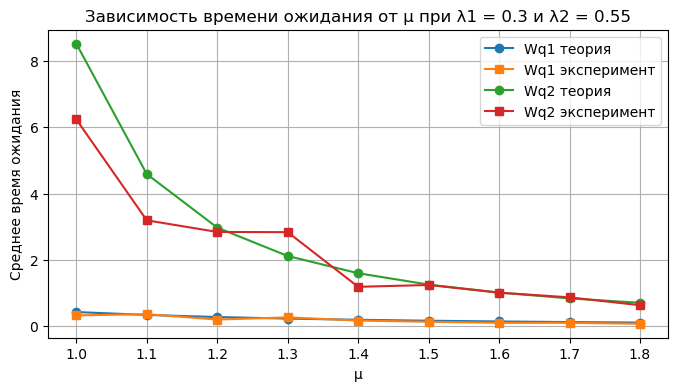

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(table_mu['μ'], table_mu['Wq1 теор'], marker='o', label='Wq1 теория')
plt.plot(table_mu['μ'], table_mu['Wq1 эксп'], marker='s', label='Wq1 эксперимент')
plt.plot(table_mu['μ'], table_mu['Wq2 теор'], marker='o', label='Wq2 теория')
plt.plot(table_mu['μ'], table_mu['Wq2 эксп'], marker='s', label='Wq2 эксперимент')
plt.xlabel('μ')
plt.ylabel('Среднее время ожидания')
plt.title('Зависимость времени ожидания от μ при λ1 = 0.3 и λ2 = 0.55')
plt.grid(True)
plt.legend()
plt.show()